# Practical 4 & 5: Solving the Shallow Ice-Sheet Approximation Model

Anna Chen (yc4406)

## The model

The ice-sheet model we have derived is defined by

$$
\frac{\partial H}{\partial t} = \dot{b_i}(x) - \frac{\partial q}{\partial x},
$$

$$
q = -\frac{2A}{n+2} \left(\rho g \alpha \right)^n  H^{n+2}  
$$

where $\dot{b_i}$ is the ice-equivalent rate of accumulation on the ice sheet surface, $x$ is the horizontal coordinate, $H$ is the ice thickness, $t$ is time, $q$ is the depth-intergrated flux per unit width (hereafter, flux), $A$ is the flow parameter from the flow law, $n$ is the exponent from the flow law, $\rho$ is the density of ice, $g$ is acceleration due to gravity, and $\alpha$ is the surface slope $\left(= - \frac{\partial H}{\partial x}\right)$.

We will use a a simple finite-difference scheme. It approximates the derivatives as differences, e.g.

$$
\frac{\partial H}{\partial t} = \frac{H^{j+1}-H^{j}}{\Delta t}
$$

where $j$ refers to which 'time step' we are looking at and $\Delta t$ is the time interval between timesteps. 

Applying this approximation (or more precisly a 'centered-difference version of the approximation) to the spatial derivatives gives

$$
\frac{\partial q}{\partial x}\bigg\rvert^j = \frac{ q^j_{i+1} - q^j_{i-1}}{2 \Delta x}
$$ 

and

$$
\frac{\partial H}{\partial x}\bigg\rvert^j = \frac{ H^j_{i+1} - H^j_{i-1}}{2 \Delta x}.
$$



Substituting these into our model gives

$$
\frac{H^{j+1}-H^{j}}{\delta t} = a_i - \frac{\partial q^j_{i+1} - q^j_{i-1}}{2 \Delta x},
$$


$$
q^j_i = -\frac{2A}{n+2} \left(\rho g  \right)^n  {H^j_i}^{n+2}  \left(\frac{H^j_{i+1} - H^j_{i-1}}{2\Delta x}\right)^n
$$


Note that although in class we defined $\alpha = - \frac{H^j_{i+1} - H^j_{i-1}}{2\Delta x}$, we change it to a positive sign because we only should have one negative sign in the total $q^j_i$ equation (and we already have it in the front), and also we've defined in Step 7's simulation that our spacestep is $\Delta x$, not $2\Delta x$.


We impose the surface mass balance (SMB) as a simple linear function of distance:

$$
a = 10^{-4}\left(\frac{X}{3}-x\right), 
$$

where $X$ is the length of the spatial domain. 

We will also impose a no-flow boundary condition on the right hand side. Let's think about what this looks like in our model as we go along.

We will also assume a flat bed topography.

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

## 1. Space and Time Grids

In [2]:
# Space Grid
X = 40000                           # Maximum length of size the model is 40000m
dx = 200                            # Each step in space is 200m
x = np.linspace(0,X,round(X/dx))    # Space array
Lx = x.size                         # Length of the space array

# Time Grid
T = 3000                            # Maximum length of time the model is allowed to run is 3000 years
dt = 0.004                          # Each step in time is 1 year
t = np.linspace(0,T,round(T/dt))    # Time array
Lt = t.size                         # Length of the time array

# Check length of both arrays
print(f"The length of the space array is {Lx}. \n The length of the time array is {Lt}.")

The length of the space array is 200. 
 The length of the time array is 750000.


In [3]:
# Set up staggered space array
x_stag = x[0:-1] + dx * 0.5         # Each point in x_stag is the average of the x value before and after it
Lx_stag = x_stag.size

# Check length of staggered space array (should be 1 less than the length of x)
print(f"The length of the staggered space array is {Lx_stag}.")

The length of the staggered space array is 199.


## 2. Physical Constants

This is copied from the Level 2 notebook.

In [4]:
# Copied from Level 2 notebook
n = 3.0                              # The flow law exponent
seconds_per_year = 365*24*60*60      # approximate number of seconds in year
A = 24*10**(-25) * seconds_per_year  # The flow law parameter, units [Pa a] (original value from Cuffey and Paterson 24e-25, units Pa s]
rho = 917                            # ice density,  units [kg/m^3]
g = 10                               # acceleration due to gravity, units [m/s^2]
e = 0.0001                           # used to prevent ice thickness from reaching zero

## 3. Preallocate the ice thickness array
For simplicity, we will save the ice thickness at every time step. To do this most efficiently, we 'pre-allocate' the memory for the array by creating an array the right width and height consisting of zeros. Notice that the time domain will correspond to the first index of `H` and the spatial domain will correspond to the second. 

In [5]:
# First index (rows) of H corresponds to time
# Second index (columns) of H corresponds to space
H = np.zeros((Lt, Lx))

# Check shape of H
H.shape

(750000, 200)

## 4. Define initial conditions
Because our model contains a time derivative of ice thickness $H$, we need to assign $H$ an initial condition. This will be arbitrary, so we better make sure that the conclusions we draw from simulations do not rely on this arbitrary choice. 

For simicity we will make $H$ uniform initally and equal to `e`.

In [6]:
# Make the first row of H be e
H[0, :] = e

## 5. Prescribe the surface mass balance
The model is forced by the surface mass balance $\dot{b_i}$. For simplicity, we will prescribe $\dot{b_i}$ as a simple linear function of distance. 

$$
\dot{b_i} = 10^{-4} \left( \frac{X}{3} - x \right)
$$

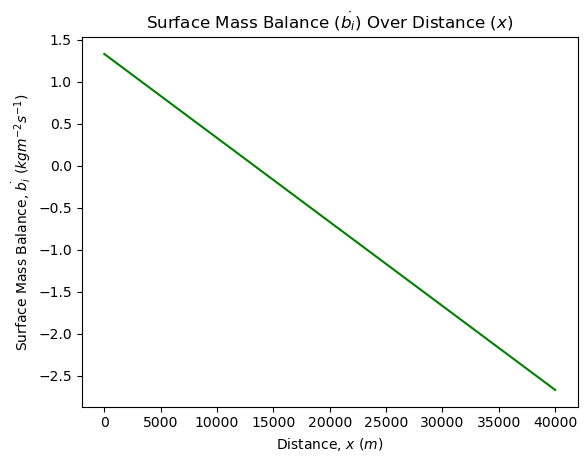

In [7]:
# Define surface mass balance b
b = lambda x: 10**-4 * (X / 3 - x)       # Recall X is the max spatial length of 40000 m
b_array = np.asarray(b(x))

# Plot surface mass balance against distance
plt.figure()
plt.plot(x, b(x), 'g-')
plt.xlabel(r'Distance, $x$ ($m$)')
plt.ylabel(r'Surface Mass Balance, $\dot{b_i}$ ($kg m^{-2} s^{-1}$)')
plt.title(r'Surface Mass Balance ($\dot{b_i}$) Over Distance ($x$)')
plt.show()

This function says that $\dot{b_i}$ is positive on the left of our model domain and decreases linearly with $x$, passing zero at $x=1500$ m. This is probably not how SMB really works; $\dot{b_i}$ is more likely to be a function of elevation $\left(\dot{b_i}(H)\right)$ rather than distance $\left(\dot{b_i}(x)\right)$, but with a flat bed like this, $\dot{b_i}(H)$ leads to unstable ice sheet growth or decay, so the only steady state we can reach is $H(x) = 0$, which isn't very interesting. So we will stick with this unrealistic way of imposing $\dot{b_i}$ for now and we can always come back to this later and look at what happens when it is prescribed in a more realistic way. 

## 6. Prepare for plotting
The simulation (below) will involve iteratively solving the model equations at each time step. This will happen in a for loop.

To track the progress of  simulations we will want to print a message from within our for loop, but not in every iteration because there will be len(t) iterations, which is thousands. The simplest solution is to only print a message whenever the remainder of dividing the iteration number by some large number `print_period` is zero. 

Note that a nicer solution would be to use a package which will print a progress bar like [tqdm](https://tqdm.github.io/), but this requires installing a new package, so we won't do that right now. 

In [8]:
print_period = 30000

## 7. Run the simulation
Finally, we are ready to run our simulation. 

We will loop through every time step. In each iteration, $j$ we will use the ice thickness from the previous time, $H^{j-1}$ step to compute the following:

1. the ice thickness on the staggered grid,
2. the surface slope, $\alpha$, on the staggered grid, using (1) 
3. the flux on the staggered grid, using (1) and (2), and 
4. the ice thickness at the current time step on the normal grid, using (3) and $\dot{b_i}$ 

The code in cell below is numbered to show where each step is happening. 

The code in the cell below also times the executiono the model with `%%time` and applies the boundary conditions. 

$$
\frac{H^{j+1}-H^{j}}{\delta t} = a_i - \frac{q^j_{i+1} - q^j_{i-1}}{2 \Delta x},
$$


$$
q^j_i = -\frac{2A}{n+2} \left(\rho g  \right)^n  {H^j_i}^{n+2}  \left(\frac{H^j_{i+1} - H^j_{i-1}}{2\Delta x}\right)^n
$$


In [9]:
# pre-define flux and coefficients used for flux function
#q = np.zeros((Lt, Lx_stag))
#q_coeff = -2.0 * A / (n + 2.0) * (rho * g) ** n

In [10]:
%%time

# pre-define flux and coefficients used for flux function
q = np.zeros((Lt, Lx-1))
q_coeff = -2.0 * A / (n + 2.0) * (rho * g) ** n

for timestep in np.arange(1, Lt):

    # only print a message when the remainder of the timestep number and `print_period` is zero.
    if timestep % print_period == 0:
        print(f'{t[timestep]:.1f} out of {T} years')

    # save the old thickness vector
    H_old = H[timestep - 1, :]

    # (1) compute H on the staggered grid (average of neighboring normal-grid H values)
    H_stag = 0.5 * (H_old[1:] + H_old[:-1])

    # (2) compute the surface slope on the staggered grid
    alpha = (H_old[1:] - H_old[:-1]) / dx

    # (3) compute the flux on the staggered grid
    q[timestep, :] = q_coeff * H_stag ** (n + 2.0) * (alpha ** n)

    # (4) compute the ice thickness at the current time step
    dqdx = (q[timestep, 1:] - q[timestep, :-1]) / dx

    H[timestep, 1:-1] = np.maximum(e, H_old[1:-1] + dt * (b_array[1:-1] - dqdx))

    # enforce minimum thickness and boundary conditions
    H[timestep, 0] = H[timestep, 1]
    H[timestep, -1] = e

120.0 out of 3000 years
240.0 out of 3000 years
240.0 out of 3000 years
360.0 out of 3000 years
360.0 out of 3000 years


KeyboardInterrupt: 

## 8. Plot the results
The simplest result to plot is the final ice thickness, $H(x,T)$:

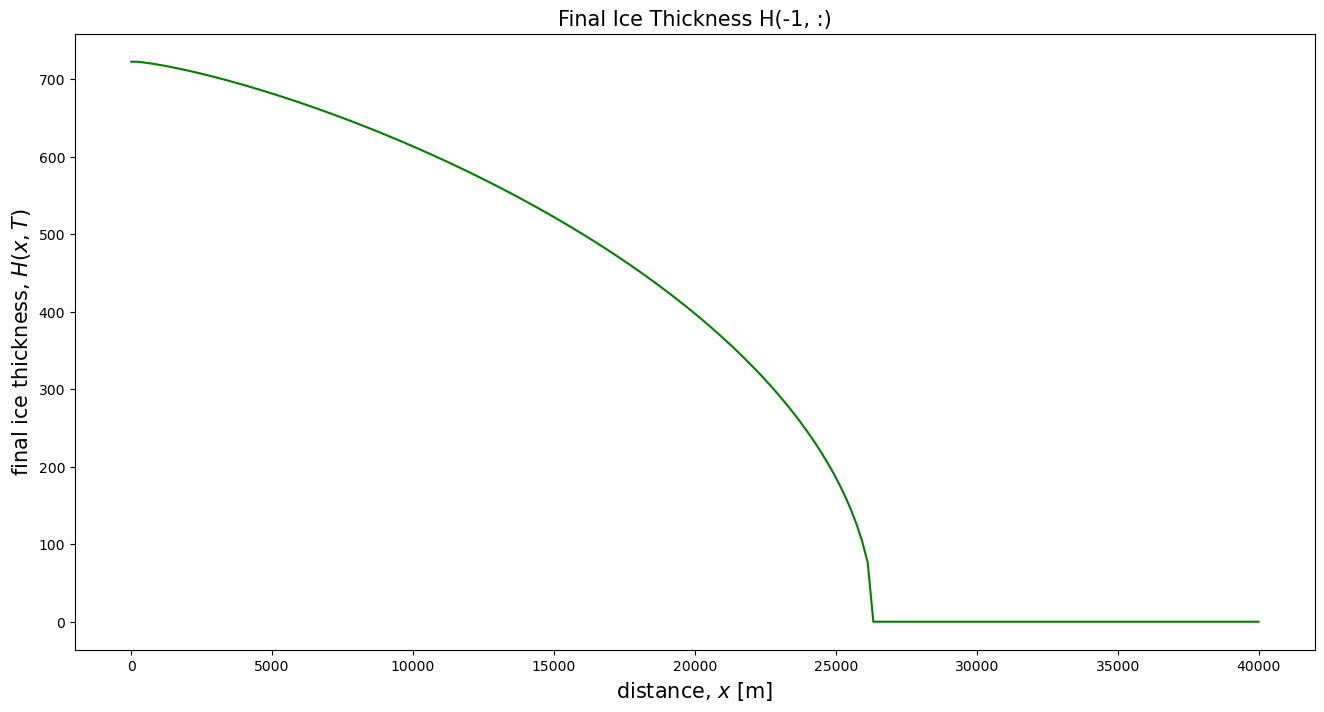

In [ ]:
plt.figure(figsize=(16, 8))
plt.plot(x, H[-1, :], 'g-')
plt.xlabel('distance, $x$ [m]', size = 15)
plt.ylabel('final ice thickness, $H(x,T)$', size = 15)
plt.title('Final Ice Thickness H(-1, :)', size = 15)
plt.show()

We can also plot the thickness profile $H(x)$ from every 10,000th timestep. We see that the glacier grows from the initial conditions of $H(t=0,x) = e$ and advances until we get a characteristic convex ice-sheet shape. This is caused by the interplay of thinning towards the terminus, the dependence of flux on thickness, and the spatial variability of flux. 

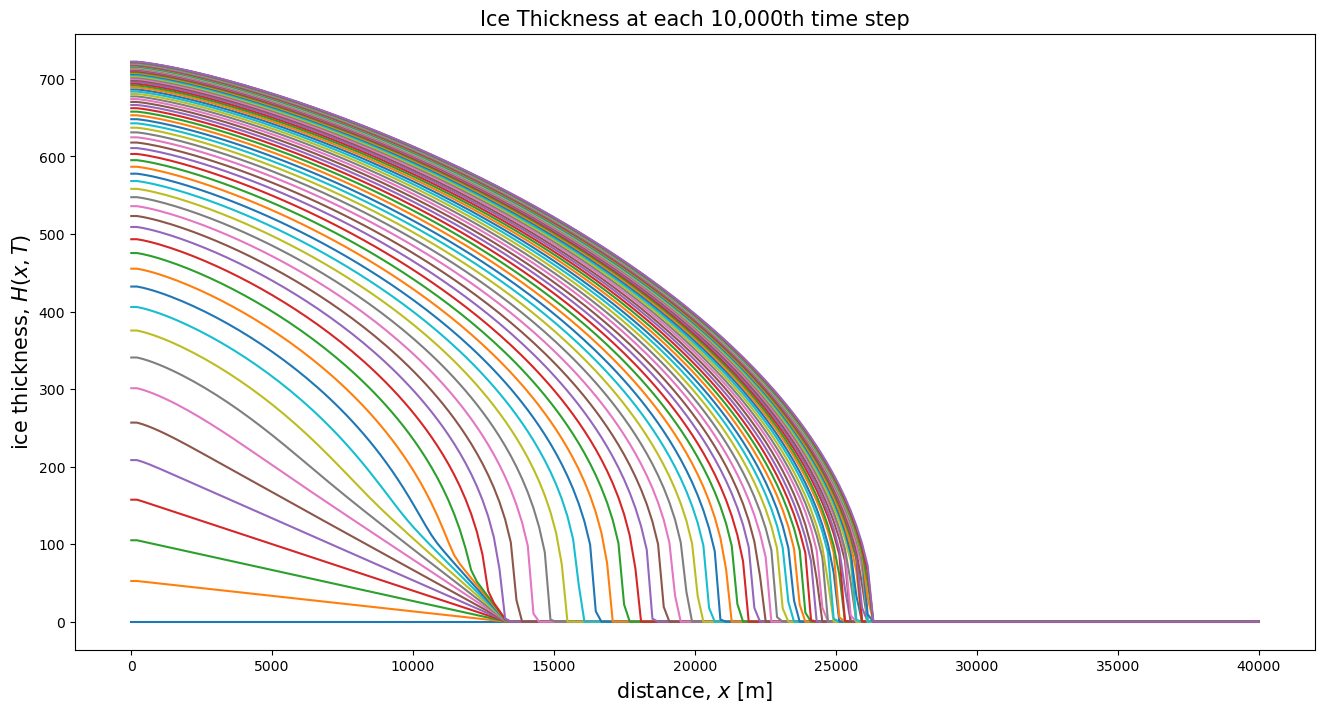

In [ ]:
plt.figure(figsize=(16, 8))
plt.plot(x, np.transpose(H[0:-1:10000, :]))
plt.xlabel(r'distance, $x$ [m]', size = 15)
plt.ylabel(r'ice thickness, $H(x,T)$', size = 15)
plt.title('Ice Thickness at each 10,000th time step', size = 15)
plt.show()

Another kind of plot we can make is a time series of ice thickness from a particualr location. In this case we will plot the icce thickness on the left side of the domain - the ice divide. 

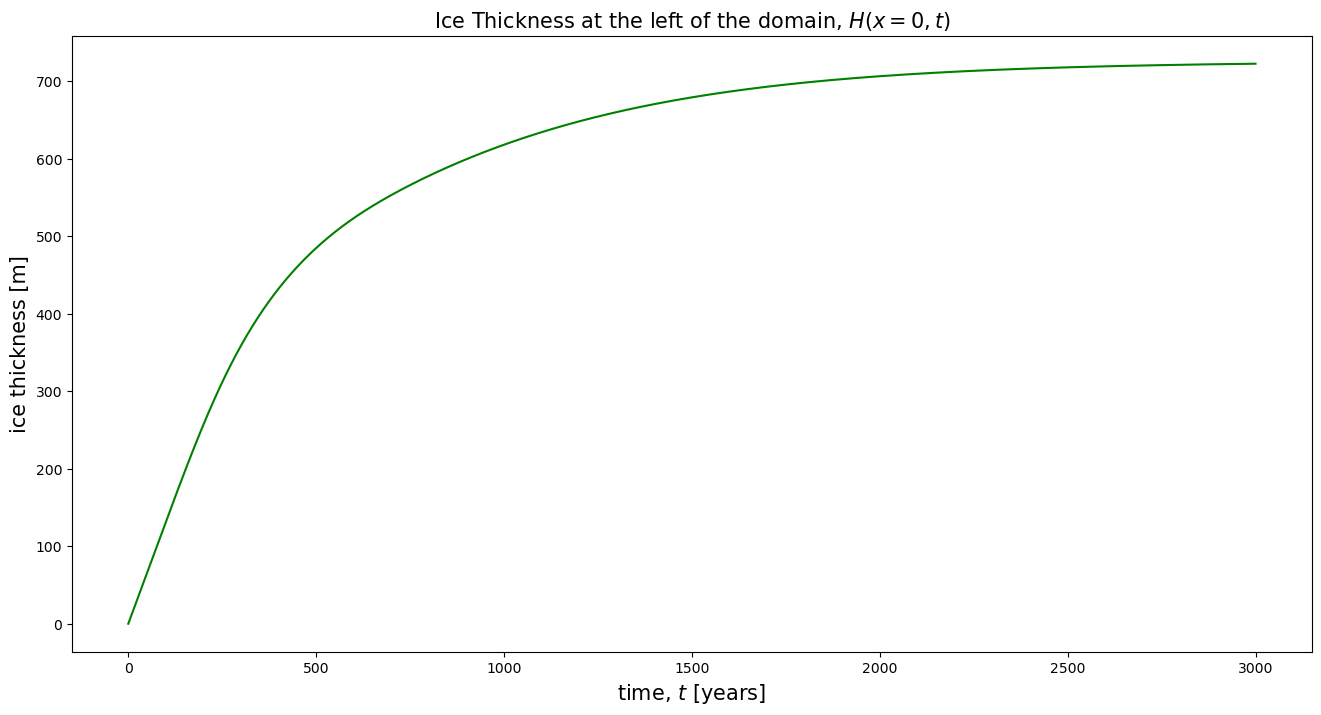

In [ ]:
plt.figure(figsize=(16, 8))
plt.plot(t, H[:, 0], 'g-')
plt.xlabel(r'time, $t$ [years]', size = 15)
plt.ylabel('ice thickness [m]', size = 15)
plt.title('Ice Thickness at the left of the domain, $H(x=0,t)$', size = 15)
plt.show()

We can also plot the final ice flux as follows.

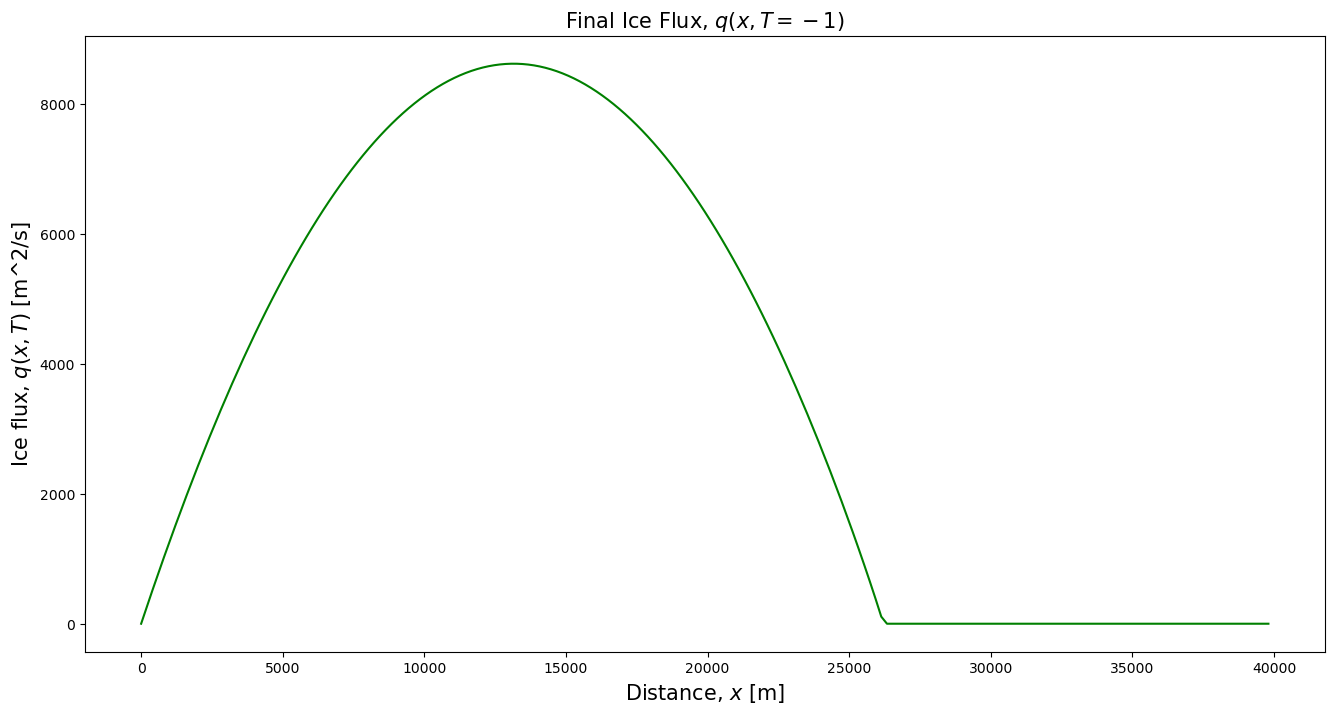

In [ ]:
plt.figure(figsize=(16, 8))
plt.plot(x[0:-1], q[-1, :], 'g-')
plt.xlabel('Distance, $x$ [m]', size = 15)
plt.ylabel('Ice flux, $q(x,T)$ [m^2/s]', size = 15)
plt.title('Final Ice Flux, $q(x,T=-1)$', size = 15)
plt.show()

# Practical 5: Extending the Shallow-ice model

## 1. Sensitivity to model parameters
- make your code into a function so it can easily be called while varying A and recording some metric of the ice sheet once it is steady state. 

- write a simple script to call the function many times with different physical parameters and plot the metric as a fn. of A (with A along the horizontal axis). 

In [11]:
# Import packages again for Practical 5
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

In [18]:
def shallow_ice(A = 24*10**(-25) * 365*24*60*60, 
                X = 40000, 
                dx = 200,
                T = 6000, 
                dt = 0.004,
                e = 0.0001,
                print_true=False,
                print_period = 80000,
                plot_true=False):
    """ Shallow-ice model with variable parameters, including the flow law parameter A.
    Does not print progress of simulation nor plots by default.

    Parameters:
    -----------------
        A: float
            Flow Law Parameter units [Pa a]
            Original value from Cuffey and Paterson 24e-25, units [Pa s]
        
        X: float
            Maximum length of size the model units [m]
        
        dx: float
            Size of each space step [m]
        
        T: float
            Maximum length of time the model is allowed to run, units [year]
        
        dt: float
            Size of each time step [year]

        e: float
            Parameter used to prevent ice thickness from reaching zero
        
        print_true: boolean
            Boolean parameter used to decide whether to report progress of simulation
        
        print_period: float
            When the time reaches a multiple of this number, the progress will be printed
        
        plot_true: boolean
            Boolean parameter used to decide whether to print plots
    
    Returns:
    ----------
        H: 2D numpy array
            2D array with rows being time (Lt) and columns being space (Lx)
        
        x: 1D numpy array
            1D array of space grids
        
        q: 2D numpy array
            2D array with rows being time (Lt) and columns being 1 less than full space grid (Lx-1)
        
        plots if plot_true

    """
    # Space Grid
    x = np.linspace(0,X,round(X/dx))    # Space array
    Lx = x.size                         # Length of the space array

    # Time Grid
    t = np.linspace(0,T,round(T/dt))    # Time array
    Lt = t.size                         # Length of the time array

    # Set up staggered space array
    x_stag = x[0:-1] + dx * 0.5         # Each point in x_stag is the average of the x value before and after it
    Lx_stag = x_stag.size

    # Set up parameters
    n = 3.0                              # The flow law exponent
    rho = 917                            # ice density,  units [kg/m^3]
    g = 10                               # acceleration due to gravity, units [m/s^2]

    # Preallocate the ice thickness array
    H = np.zeros((Lt, Lx))
    H[0, :] = e

    # Define surface mass balance b
    b = lambda x: 10**-4 * (X / 3 - x)       # Recall X is the max spatial length of 40000 m
    b_array = np.asarray(b(x))

    # pre-define flux and coefficients used for flux function
    q = np.zeros((Lt, Lx-1))
    q_coeff = -2.0 * A / (n + 2.0) * (rho * g) ** n

    for timestep in np.arange(1, Lt):
        # only print a message when the remainder of the timestep number and `print_period` is zero.
        if print_true:
            if timestep % print_period == 0:
                print(f'{t[timestep]:.1f} out of {T} years')

        # save the old thickness vector
        H_old = H[timestep - 1, :]

        # (1) compute H on the staggered grid (average of neighboring normal-grid H values)
        H_stag = 0.5 * (H_old[1:] + H_old[:-1])

        # (2) compute the surface slope on the staggered grid
        alpha = (H_old[1:] - H_old[:-1]) / dx

        # (3) compute the flux on the staggered grid
        q[timestep, :] = q_coeff * H_stag ** (n + 2.0) * (alpha ** n)

        # (4) compute the ice thickness at the current time step
        dqdx = (q[timestep, 1:] - q[timestep, :-1]) / dx

        H[timestep, 1:-1] = np.maximum(e, H_old[1:-1] + dt * (b_array[1:-1] - dqdx))

        # enforce minimum thickness and boundary conditions
        H[timestep, 0] = H[timestep, 1]
        H[timestep, -1] = e
    
    if plot_true:
        # Plot results
        fig = plt.figure(figsize=(16,8))

        axes = fig.add_subplot(4,1,1)
        axes.plt(x, H[-1, :], 'g-')
        axes.set_xlabel('distance, $x$ [m]')
        axes.set_ylabel('final ice thickness, $H(x,T)$')
        axes.set_title('Final Ice Thickness H(-1, :)')

        axes = fig.add_subplot(4,1,2)
        axes.plt(x, np.transpose(H[0:-1:10000, :]))
        axes.set_xlabel(r'distance, $x$ [m]')
        axes.set_ylabel(r'ice thickness, $H(x,T)$')
        axes.set_title('Ice Thickness at each 10,000th time step')

        axes = fig.add_subplot(4,1,3)
        axes.plt(t, H[:, 0], 'g-')
        axes.set_xlabel(r'time, $t$ [years]')
        axes.set_ylabel('ice thickness [m]')
        axes.set_title('Ice Thickness at the left of the domain, $H(x=0,t)$')

        axes = fig.add_subplot(4,1,4)
        axes.plt(x[0:-1], q[-1, :], 'g-')
        axes.set_xlabel('Distance, $x$ [m]')
        axes.set_ylabel('Ice flux, $q(x,T)$ [m^2/s]')
        axes.set_title('Final Ice Flux, $q(x,T=-1)$')

        plt.show()
    
    return H, x, q

In [19]:
# Set up some A that we want to try out
# A represents how soft the ice is
A_vectors = np.linspace(1,26,5)*10**(-25) * 365*24*60*60
model_metric = []
H_final = []
q_final = []

for A in A_vectors:
    print(f"A = {A}")
    H, x, q = shallow_ice(A = A,          # Uses A from A_vectors
                          dt = 0.01)      # Make the model run faster by reducing time step size
    model_metric.append(H[-1,0])        # This list gathers the final height at the ice divide (leftmost domain)
    H_final.append(H[-1,:])             # This list gathers the final height of the entire space domain
    q_final.append(q[-1,:])             # This list gathers the final ice flux of the entire space domain

A = 3.1536e-18
A = 2.2863600000000002e-17
A = 4.25736e-17
A = 6.228360000000002e-17
A = 8.199360000000001e-17


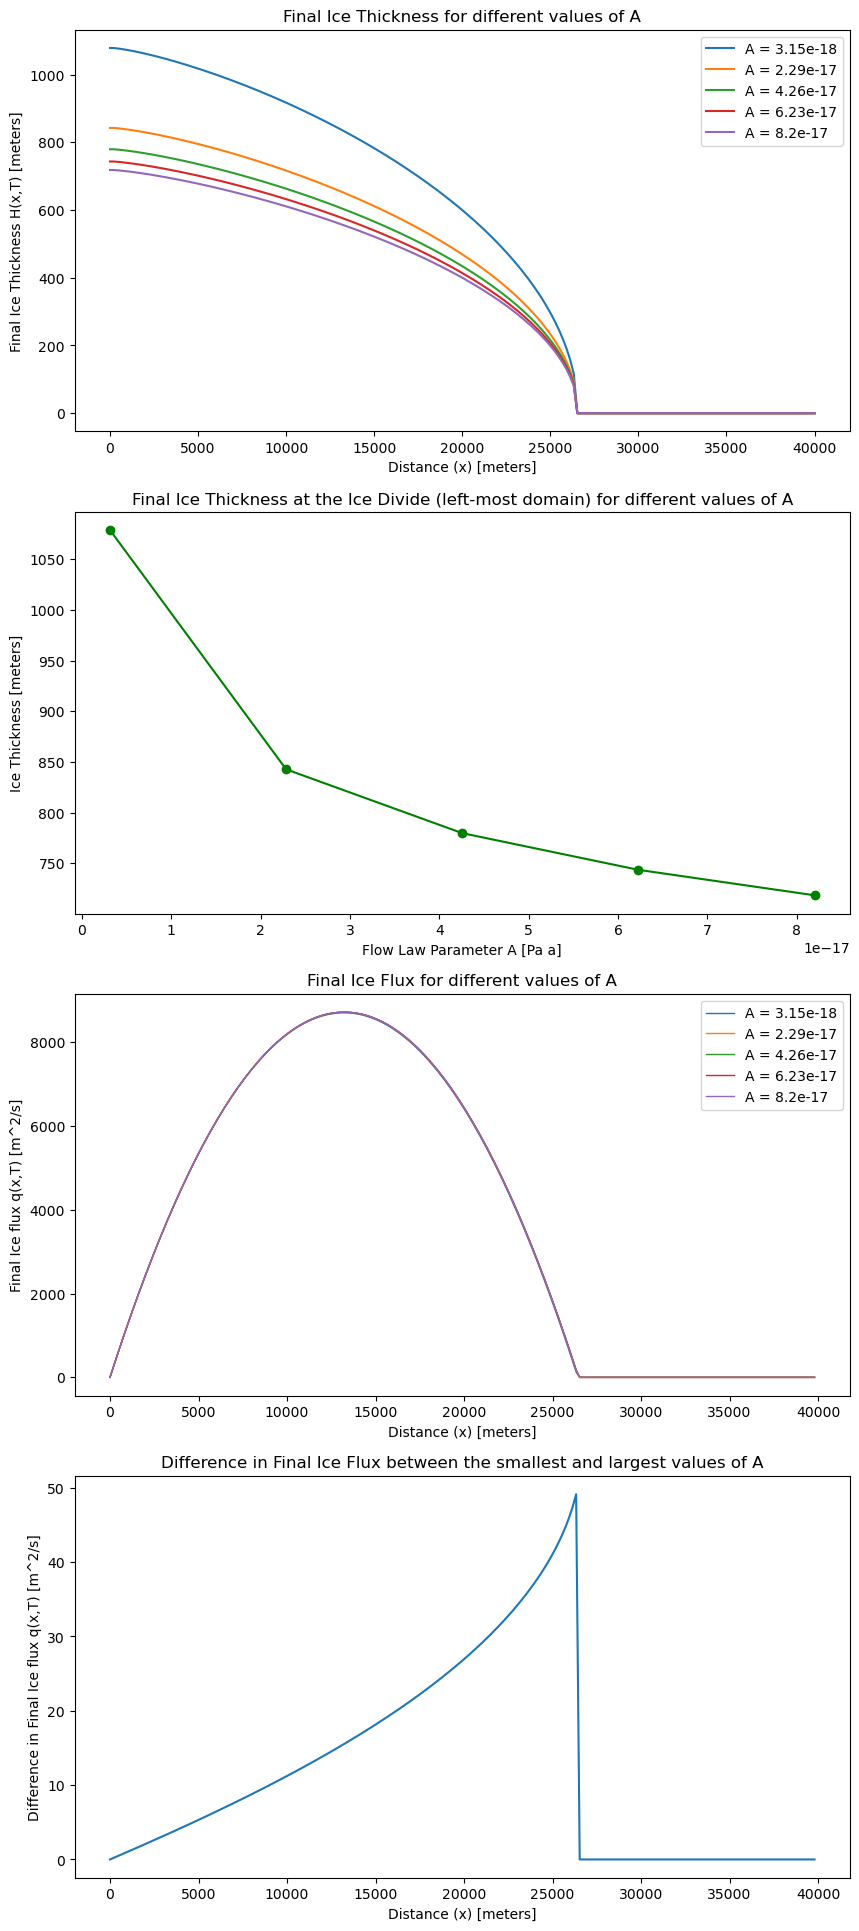

In [21]:
# To make the difference between final ice flux metrics clearer, compute the difference between results from different A values
q_diff = q_final[-1] - q_final[0]

# Plot all figures
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(10, 24))

for i in range(1,6):
    ax1.plot(x, np.array(H_final[i-1]).T, label = f'A = {A_vectors[i-1]:.3g}')
ax1.set_xlabel('Distance (x) [meters]')
ax1.set_ylabel('Final Ice Thickness H(x,T) [meters]')
ax1.set_title('Final Ice Thickness for different values of A')
ax1.legend()

ax2.plot(A_vectors, model_metric, 'go-')
ax2.set_xlabel('Flow Law Parameter A [Pa a]')
ax2.set_ylabel('Ice Thickness [meters]')
ax2.set_title('Final Ice Thickness at the Ice Divide (left-most domain) for different values of A')

for i in range(1,6):
    ax3.plot(x[0:-1], np.array(q_final[i-1]).T, linewidth = 1, label = f'A = {A_vectors[i-1]:.3g}')
ax3.set_xlabel('Distance (x) [meters]')
ax3.set_ylabel('Final Ice flux q(x,T) [m^2/s]')
ax3.set_title('Final Ice Flux for different values of A')
ax3.legend()

ax4.plot(x[0:-1], np.array(q_diff).T)
ax4.set_xlabel('Distance (x) [meters]')
ax4.set_ylabel('Difference in Final Ice flux q(x,T) [m^2/s]')
ax4.set_title('Difference in Final Ice Flux between the smallest and largest values of A')

plt.show()

## 2. Transience
- write a new function which runs the model with a sinusoidally-varying equilibrium line position. 
    
- plot a time-varying metric (e.g. ice thickness at some location) against time. 

- plot this metric against equilibrium line position as both vary throughout a model run. (this is a phase-space plot).

- examine how the shape of the phase-space plot changes as you vary the period of the 	sinusoidal variation in equilibrium line position.

In [13]:
def shallow_ice_transient(A = 24*10**(-25) * 365*24*60*60, 
                         X = 40000, 
                         dx = 200,
                         T = 3000, 
                         dt = 0.004,
                         e = 0.0001,
                         elx = 1/3,
                         period = 100,  # Period of ELX oscillation in years
                         amplitude = 0.2,  # Fractional amplitude of ELX oscillation
                         print_true=False,
                         print_period = 80000):
    """Shallow-ice model with sinusoidally varying equilibrium line position.
    
    The surface mass balance (SMB) varies as the equilibrium line position oscillates:
    SMB = b0 * (X * elx * (1 + A*cos(2πt/P)) - x)
    where:
    - b0 is the base mass balance rate
    - elx is the mean equilibrium line position (as fraction of X)
    - A is the amplitude of oscillation
    - P is the period of oscillation
    - x is the distance along the domain
    
    Parameters:
    -----------
    A : float
        Flow law parameter [Pa^(-n) year^(-1)]
    X : float
        Domain length [m]
    dx : float
        Spatial step [m]
    T : float
        Total simulation time [years]
    dt : float
        Time step [years]
    e : float
        Minimum ice thickness [m]
    elx : float
        Mean equilibrium line position as fraction of X
    period : float
        Period of ELX oscillation [years]
    amplitude : float
        Amplitude of ELX oscillation as fraction of mean
    print_true : bool
        Whether to print progress
    print_period : int
        How often to print progress
        
    Returns:
    --------
    H : ndarray
        Ice thickness [m] at each time and position
    x : ndarray
        Distance along domain [m]
    t : ndarray
        Time points [years]
    elx_history : ndarray
        Equilibrium line position [m] at each time
    """
    # Space grid
    x = np.linspace(0, X, round(X/dx))    
    Lx = x.size                         
    x_stag = x[0:-1] + dx * 0.5        
    Lx_stag = x_stag.size

    # Time grid
    t = np.linspace(0, T, round(T/dt))    
    Lt = t.size                         

    # Physical parameters
    n = 3.0                             
    rho = 917                           
    g = 10                              
    
    # Initialize arrays
    H = np.zeros((Lt, Lx))
    H[0, :] = e
    q = np.zeros((Lt, Lx-1))
    elx_history = np.zeros(Lt)
    
    # Constants for flux and SMB calculations
    q_coeff = -2.0 * A / (n + 2.0) * (rho * g) ** n
    b0 = 10**-4  # Base SMB rate [m/year]

    for timestep in range(1, Lt):
        # Print progress if requested
        if print_true and timestep % print_period == 0:
            print(f'{t[timestep]:.1f} out of {T} years')
            
        # Calculate current equilibrium line position
        current_elx = X * elx * (1 + amplitude * np.cos(2 * np.pi * t[timestep] / period))
        elx_history[timestep] = current_elx
        
        # Calculate surface mass balance
        b = lambda x: b0 * (current_elx - x)
        b_array = np.asarray(b(x))
        
        # Save previous timestep
        H_old = H[timestep - 1, :]
        
        # Calculate on staggered grid
        H_stag = 0.5 * (H_old[1:] + H_old[:-1])
        alpha = (H_old[1:] - H_old[:-1]) / dx
        
        # Calculate flux
        q[timestep, :] = q_coeff * H_stag**(n + 2.0) * alpha**n
        
        # Update thickness
        dqdx = (q[timestep, 1:] - q[timestep, :-1]) / dx
        H[timestep, 1:-1] = np.maximum(e, H_old[1:-1] + dt * (b_array[1:-1] - dqdx))
        
        # Boundary conditions
        H[timestep, 0] = H[timestep, 1]  # No-flux at divide
        H[timestep, -1] = e              # Zero thickness at margin
    
    return H, x, t, elx_history

In [14]:
# Test the transient model with different periods
periods = [50, 100, 200, 400]  # Different periods to test
results = []

for p in periods:
    print(f"Running simulation with period = {p} years")
    H, x, t, elx = shallow_ice_transient(period=p, T=2000)
    results.append((H, elx))

Running simulation with period = 50 years
Running simulation with period = 100 years
Running simulation with period = 200 years
Running simulation with period = 400 years


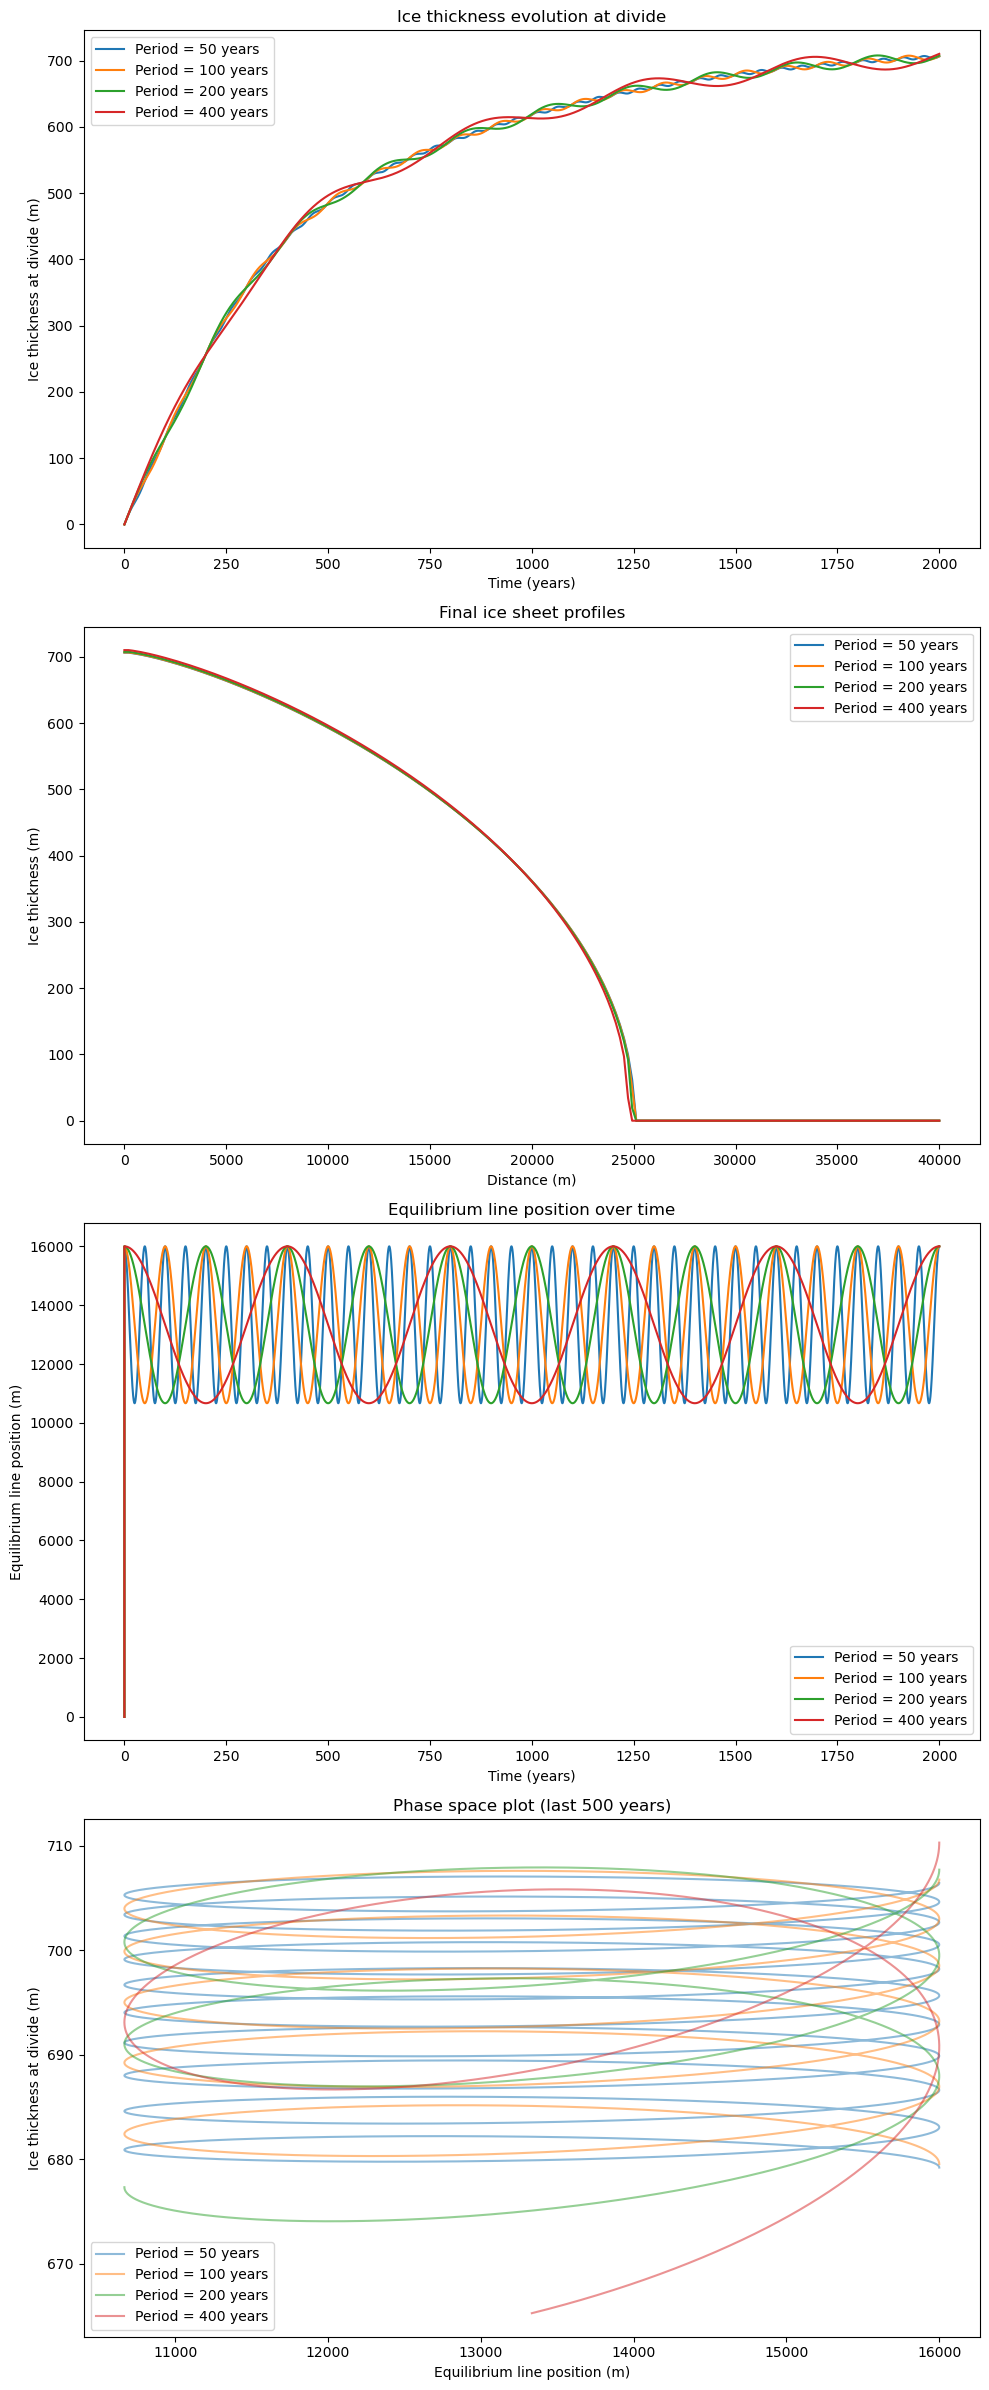

In [ ]:
# Create plots
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(10, 24))

# 1. Plot ice thickness at divide vs time for different periods
for i, p in enumerate(periods):
    H, elx = results[i]
    ax1.plot(t, H[:, 0], label=f'Period = {p} years')
ax1.set_xlabel('Time (years)')
ax1.set_ylabel('Ice thickness at divide (m)')
ax1.set_title('Ice thickness evolution at divide')
ax1.legend()

# 2. Plot final ice sheet profiles
for i, p in enumerate(periods):
    H, elx = results[i]
    ax2.plot(x, H[-1, :], label=f'Period = {p} years')
ax2.set_xlabel('Distance (m)')
ax2.set_ylabel('Ice thickness (m)')
ax2.set_title('Final ice sheet profiles')
ax2.legend()

# 3. Plot equilibrium line position vs time
for i, p in enumerate(periods):
    H, elx = results[i]
    ax3.plot(t, elx, label=f'Period = {p} years')
ax3.set_xlabel('Time (years)')
ax3.set_ylabel('Equilibrium line position (m)')
ax3.set_title('Equilibrium line position over time')
ax3.legend()

# 4. Phase space plot (last 500 years)
start_idx = int(len(t) - 500/0.004)  # Index for last 500 years
for i, p in enumerate(periods):
    H, elx = results[i]
    ax4.plot(elx[start_idx:], H[start_idx:, 0], 
             label=f'Period = {p} years', alpha=0.5)
ax4.set_xlabel('Equilibrium line position (m)')
ax4.set_ylabel('Ice thickness at divide (m)')
ax4.set_title('Phase space plot (last 500 years)')
ax4.legend()

plt.show()

**Notes from class/talking with Jonny:**

At every time step, use a different SMB array (different b). Calculate the b based on temporal variability.

How we previously defined the SMB array (b):

`
b = lambda x: 10**-4 * (X / 3 - x)
`

`
b_array = np.asarray(b(x))
`

Where X is the max spatial length of 40000 m.

Define new climate variability as a sin function to simulate climate changes. Eg. define X/3 as a function of time

`
b(x) = b0 * (X*elx*(1 + elx_variability(timestep))-x)
`

`
elx_variability = amplitude * np.cos(2 * np.pi * t / period)
`

And see how elx changes up and down throughout time.